In [1]:
# importing the required libraries

import torch
import torch.nn as nn
from torch.optim import SGD
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Downloading the images from MNIST dataset and creating the data loaders

# Transform the dataset into tensor and normalize it
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Normalization
])

# Download training dataset
full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# Download test dataset
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split training into training + validation
train_dataset, val_dataset = random_split(full_train_dataset, [55000, 5000])

# Creating DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) #Shuffing enabled to shuffle the dataset every time while training
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

100%|██████████| 9.91M/9.91M [00:00<00:00, 36.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.04MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.97MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.25MB/s]


In [3]:
# Creating neural network class

class MyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.Matrix1 = nn.Linear(28**2, 100)
        self.Matrix2 = nn.Linear(100, 50)
        self.Matrix3 = nn.Linear(50, 10)
        self.R = nn.ReLU()                # Activation function for creating non linearity

    def forward(self, x):
        x = x.view(-1, 28**2)             # [batch, 1, 28, 28] → [batch, 784]
        x = self.R(self.Matrix1(x))       # Matrix multiplication
        x = self.R(self.Matrix2(x))
        x = self.Matrix3(x)
        return x.squeeze()                # Remove unnecessary dimensions

model = MyNetwork()                       # Creating object of MyNetwork

In [6]:
# Training Function
def train_model(dl, obj, n_epochs=10):     # Increase the n_epoch (number of epoch) to increase the accuracy
    opt = SGD(obj.parameters(), lr=0.01)   # Stochastic gradient descent for optimization
    L = nn.CrossEntropyLoss()              # Cross entropy loss function

    losses = []
    epochs = []
    for epoch in range(n_epochs):

        N = len(dl)
        obj.train()

        for i, (x, y) in enumerate(dl):
            # Update the weights of the network
            opt.zero_grad()
            loss_value = L(obj(x), y)
            loss_value.backward()
            opt.step()

            # Store training data
            epochs.append(epoch + i / N)
            losses.append(loss_value.item())
    # Creating numpy array of losses and epochs for graph
    return np.array(epochs), np.array(losses)


# Train the Model
epochs, losses = train_model(train_loader, model)

In [7]:
# Evaluating Accuracy
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            max_values, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            for i in range(len(predicted)):
              if (predicted[i] == labels[i]):
                correct += 1

    return 100 * correct / total

val_acc = evaluate(model, val_loader)
test_acc = evaluate(model, test_loader)

# Printing the percentage accuracy
print(f"\nValidation Accuracy: {val_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")


Validation Accuracy: 96.00%
Test Accuracy: 96.26%


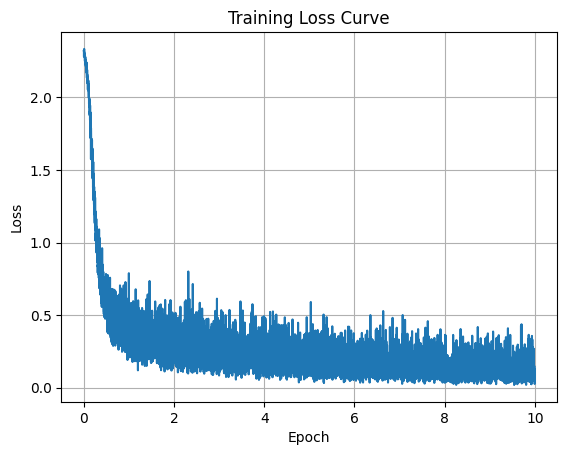

In [8]:
# Plot Training Loss Curve
plt.plot(epochs, losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

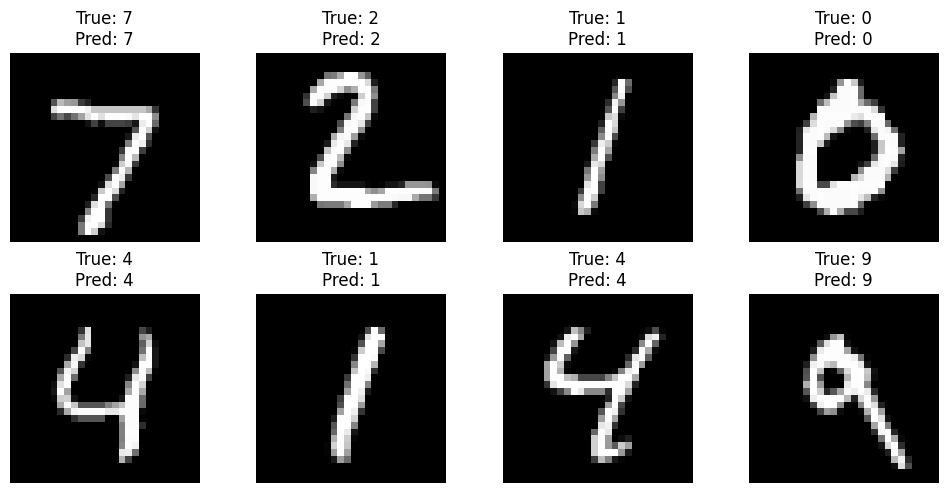

In [9]:
# Visualization of Predictions
def show_predictions(model, loader):
    model.eval()
    images, labels = next(iter(loader))
    outputs = model(images)
    max_v, preds = torch.max(outputs, 1)

    plt.figure(figsize=(10, 5))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i][0], cmap='gray')
        plt.title(f"True: {labels[i]}\nPred: {preds[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_predictions(model, test_loader)